In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ast
from sklearn.model_selection import train_test_split
from gensim.models import Word2Vec
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Load Preprocessed Data

In [2]:
data = pd.read_csv('data/fulltext_preprocessed_data.csv')
data['full_tokens'] = data['full_tokens'].apply(ast.literal_eval)
data.head()

,full_text,full_tokens,full_text_lemmatized,label
0,House Dem Aide: We Didn’t Even See Comey’s Let...,"[house, aide, even, see, letter, jason, house,...",house aide even see letter jason house aide ev...,1
1,"FLYNN: Hillary Clinton, Big Woman on Campus - ...","[hillary, clinton, big, woman, campus, ever, g...",hillary clinton big woman campus ever get feel...,0
2,Why the Truth Might Get You Fired Why the Trut...,"[truth, might, get, fired, truth, might, get, ...",truth might get fired truth might get fired oc...,1
3,15 Civilians Killed In Single US Airstrike Hav...,"[single, single, rate, american, higher, engag...",single single rate american higher engaged act...,1
4,Iranian woman jailed for fictional unpublished...,"[iranian, woman, fictional, unpublished, story...",iranian woman fictional unpublished story woma...,1


In [3]:
X = data['full_tokens']
y = data['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42) 

# Train Word2Vec

In [4]:
embedding_dim = 100

In [5]:
w2v_model = Word2Vec(
    sentences=X_train,
    vector_size=embedding_dim,
    window=5,
    min_count=2,
    sg=1,
    workers=4
)

In [ ]:
"""
window=5 -> looks at 5 words left and right (for context)
min_count=2 -> only considers words that occur more than once
Word2Vec learns word vectors using 2 algorithms - Skip-gram (sg=1) and CBOW(Continuous Bag of Words, sg=0)
CBOW works to predict a target word given context words (good for small datasets)
Skip-gram works to predict the context words given a target word (good for large datasets and when capturing rare words is important)
workers are the number of cpu cores used

This word2vec model is trained on my own X_train dataset, so the embeddings obtained are specific to that dataset.
The embeddings are actually randomly initialized and then trained just once using the specified algorithm (skip-gram or CBOW).
Hence, these are called task-specific embeddings.

Pretrained embeddings will be ones that are trained on very large, general-purpose corpus (like Wikipedia, Google News, etc.). 
These are just downloaded and not trained on our dataset.

If this part was entirely skipped, then completely random embeddings will be initialized and then learnt directly while training the 
classifier, those values will also get updated along with all the other weights in the model. These are called embeddings learned on the fly.
"""

# Create Input Data

In [6]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train)

## Generating the numerical/index sequences

In [8]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [14]:
print(X_train_seq[5],end="\n\n")
print(len(X_train_seq[5]), len(X_train.iloc[5]))

[52, 2, 90, 54, 287, 52, 2, 905, 951, 108, 90, 67, 29, 115, 31, 528, 17, 673, 253, 57, 481, 24, 2, 457, 287, 31, 67, 25, 175, 25, 4, 296, 559, 286, 370, 90, 4096, 192, 36, 324, 481, 24, 271, 2259, 2, 1397, 567, 2530, 1, 468, 1912, 84, 193, 8, 31, 32, 16, 1, 2, 205, 528, 3613, 354, 740, 8669, 103, 2205, 25, 225, 5207, 683, 48, 1, 253, 1558, 22, 2284, 193, 2415, 47, 2, 457, 60, 1859, 1747, 6657, 1, 434, 477, 1754, 1399, 2570, 284, 324, 715, 433, 1421, 3201, 324, 504, 330, 3938, 47, 662, 324, 1689, 1481, 88, 2050, 1129, 2, 31, 830, 752, 601, 43, 89, 135, 788, 2, 1, 61, 67, 279, 3041, 101, 63, 832, 178, 714, 3026, 120, 832, 34, 52, 2, 17, 1824, 2271]

139 139


In [19]:
text_lengths = [len(tokens) for tokens in data['full_tokens']]
print("Min length:", np.min(text_lengths))
print("Mean length:", np.mean(text_lengths))
print("Median length:", np.median(text_lengths))
print("90th percentile:",np.percentile(text_lengths, 90))
print("95th percentile:",np.percentile(text_lengths, 95))
print("99th percentile:",np.percentile(text_lengths, 99))
print("Max length:",max(text_lengths))

Min length: 1
Mean length: 306.23595833738926
Median length: 227.0
90th percentile: 588.0
95th percentile: 749.75
99th percentile: 1590.5499999999993
Max length: 9284


* 95% of the texts in the dataset have a length less than 750.
* But the maximum length seen is 9284 which is extremely far from the mean and 90th, 95th, and, 99th percentiles, so it is likely to be an outlier.
* The difference between the 90th and 95th percentiles is less than 200 tokens.
* The differences between 95th percentile and mean and median are between 450 and 550 tokens.
* The differences between 90th percentile and mean and median are between 280 adn 380 tokens.
* On the other hand, the differences between 99th and 95th and 90th percentiles are between 800 and 1000 tokens.
* To clearly see how and how many texts will be affected based on cutoffs, we will plot the cdfs of the lengths.

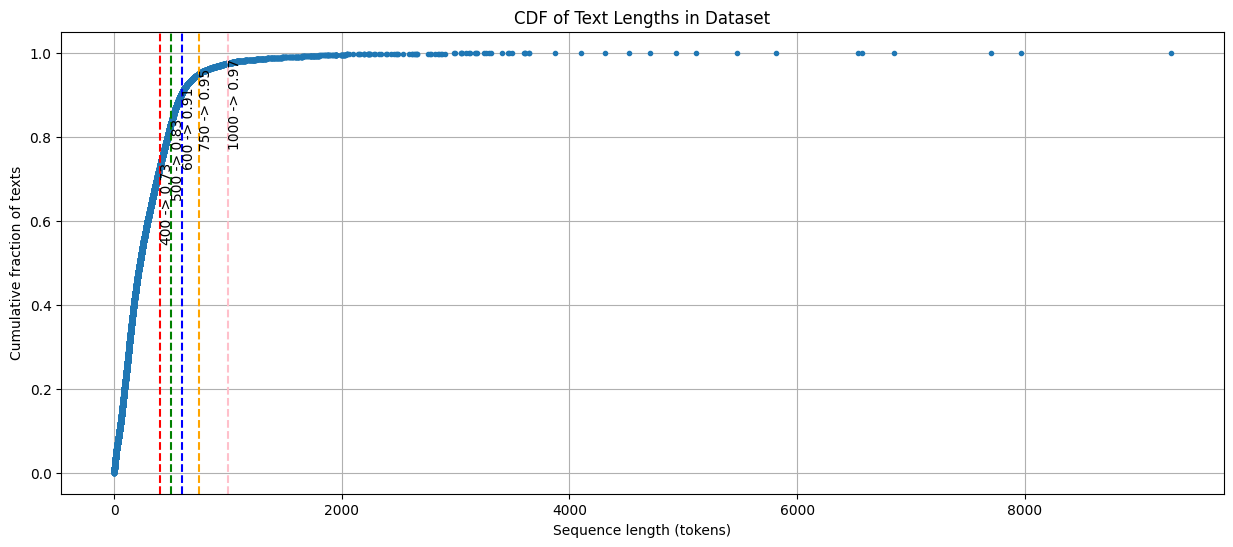

In [45]:
sorted_lengths = np.sort(text_lengths)
cdf = np.arange(1, len(sorted_lengths)+1)/len(sorted_lengths)
plt.figure(figsize=(15,6))
plt.plot(sorted_lengths, cdf, marker='.', linestyle='none')
plt.xlabel("Sequence length (tokens)")
plt.ylabel("Cumulative fraction of texts")
plt.title("CDF of Text Lengths in Dataset")
plt.grid(True)
colors = ['red', 'green', 'blue', 'orange', 'pink']
for i, cutoff in enumerate([400, 500, 600, 750, 1000]):
    fraction = np.searchsorted(sorted_lengths, cutoff, side='right')/len(sorted_lengths)
    plt.axvline(cutoff, color=colors[i], linestyle='--')
    plt.text(cutoff, fraction, f"{cutoff} -> {fraction:.2f}", rotation=90, va='center_baseline')
plt.show()

* Majority of the texts are of length less than 1000 tokens.
* Choosing the 90th percentile means 10% of the texts are truncated, while majority are padded.
* 80th to 90th percentiles are quite close. But to result in minimal loss while minimizing number of texts with padding, we will work with 80th percentile for now.

In [23]:
max_len = int(np.ceil(np.percentile(text_lengths, 90)))

## Padding the sequences

In [24]:
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

In [31]:
print(X_train_pad[5], end="\n\n")
print(len(X_train_seq[5]),len(X_train_pad[5]))

[  52    2   90   54  287   52    2  905  951  108   90   67   29  115
   31  528   17  673  253   57  481   24    2  457  287   31   67   25
  175   25    4  296  559  286  370   90 4096  192   36  324  481   24
  271 2259    2 1397  567 2530    1  468 1912   84  193    8   31   32
   16    1    2  205  528 3613  354  740 8669  103 2205   25  225 5207
  683   48    1  253 1558   22 2284  193 2415   47    2  457   60 1859
 1747 6657    1  434  477 1754 1399 2570  284  324  715  433 1421 3201
  324  504  330 3938   47  662  324 1689 1481   88 2050 1129    2   31
  830  752  601   43   89  135  788    2    1   61   67  279 3041  101
   63  832  178  714 3026  120  832   34   52    2   17 1824 2271    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0 

In [32]:
print(X_train_pad[3202], end="\n\n")
print(len(X_train_seq[3202]), len(X_train_pad[3202]))

[  120    32   153  2231   361  4291  2400  5069  1862   407    11    94
    14   260   755     6  1498    11     6  1112  1041   142   397   752
  1822  1082  3024    51   361   444     7   410   167   380   397  3453
  1964   169  2960   872    59   106   862    91    14  3219  3150     5
   515   115   809    61     1   749  1259  2960   872   612   380    29
   232    75     4   232   380   169   343   643  2511   664   840  1238
  1082  1593  3024  5069  1862  1347  2614   879  2960   872   169  8072
   239    59   106  8861  1771   708  1663    32   115  3027  1369   399
   662  2285  2146  2620   625   418 26959   845  3616   314    69     1
   665   366  2620   118    69     1   665   366  2251   845    65    69
     4   366  2281   162    91   475  1197   504  2251   250  5742     4
    41  2252  1259  2960   872     1  3150     1     3  3570   122     3
  1228    32  1888     1   310   599   125   621  1862   820  7703  9821
   140   509  3046 14302     7     1  2400    71   